# Task 2.1 - Neural Network in PyTorch

## Objective
Build a small feed-forward neural network using PyTorch on a numeric (tabular) dataset.
This notebook covers: tensors, Dataset/DataLoader, model definition, the training loop,
loss tracking, and evaluation.

## Import Libraries

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Torch version:", torch.__version__)

Torch version: 2.14.0+cpu


## Load Dataset

We use the California Housing dataset (built into scikit-learn). The goal is to predict
the median house value for a district based on features like income, average rooms, and location.

In [6]:
from sklearn.datasets import fetch_california_housing

# Load dataset as a pandas DataFrame
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Shape:", df.shape)
df.head()

Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Preprocessing

We separate features (X) from the target (y), split into train/test sets, scale the
features so they are on a similar numeric range, and convert everything into PyTorch tensors.

In [7]:
# Separate features and target
X = df.drop(columns=["MedHouseVal"]).values
y = df["MedHouseVal"].values

# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (fit ONLY on training data, then apply to both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("X_train_t shape:", X_train_t.shape)
print("y_train_t shape:", y_train_t.shape)

X_train_t shape: torch.Size([16512, 8])
y_train_t shape: torch.Size([16512, 1])


## Dataset and DataLoader

We wrap our tensors in a PyTorch Dataset, then use a DataLoader to feed the model
data in small batches during training instead of all at once.

In [8]:
class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = HousingDataset(X_train_t, y_train_t)
test_dataset = HousingDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Quick check: grab one batch
sample_X, sample_y = next(iter(train_loader))
print("Batch X shape:", sample_X.shape)
print("Batch y shape:", sample_y.shape)

Batch X shape: torch.Size([32, 8])
Batch y shape: torch.Size([32, 1])


## Define the Model

We build a small feed-forward neural network with two hidden layers. It takes 8 input
features and outputs a single number (the predicted house value).

In [9]:
class HousingNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

model = HousingNN(input_dim=X_train_t.shape[1])
print(model)

HousingNN(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## Loss Function and Optimizer

We use Mean Squared Error (MSE) as the loss, since this is a regression problem.
Adam is used as the optimizer to update the model's weights during training.

In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## Training Loop

For each epoch, we loop through all training batches. For each batch: clear old
gradients, run the model forward, calculate loss, backpropagate, and update weights.
We track the average loss per epoch to see if the model is learning.

In [11]:
num_epochs = 50
train_losses = []

for epoch in range(num_epochs):
    model.train()  # set model to training mode
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()          # 1. clear old gradients
        predictions = model(batch_X)   # 2. forward pass
        loss = criterion(predictions, batch_y)  # 3. calculate loss
        loss.backward()                # 4. backpropagate (compute gradients)
        optimizer.step()               # 5. update weights

        running_loss += loss.item() * batch_X.size(0)

    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f}")

Epoch 5/50 - Train Loss: 0.3587
Epoch 10/50 - Train Loss: 0.3160
Epoch 15/50 - Train Loss: 0.3015
Epoch 20/50 - Train Loss: 0.2934
Epoch 25/50 - Train Loss: 0.2874
Epoch 30/50 - Train Loss: 0.2835
Epoch 35/50 - Train Loss: 0.2823
Epoch 40/50 - Train Loss: 0.2775
Epoch 45/50 - Train Loss: 0.2755
Epoch 50/50 - Train Loss: 0.2745


## Evaluation

We evaluate the trained model on the test set (data it has never seen during training)
to check how well it generalizes.

In [12]:
model.eval()  # set model to evaluation mode
test_loss = 0.0

with torch.no_grad():  # no need to track gradients here
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        test_loss += loss.item() * batch_X.size(0)

test_loss = test_loss / len(test_dataset)
print(f"Test Loss (MSE): {test_loss:.4f}")

Test Loss (MSE): 0.2921


## Loss Curve

Plotting training loss over epochs helps visualize whether the model is learning
steadily, plateauing, or behaving unexpectedly.

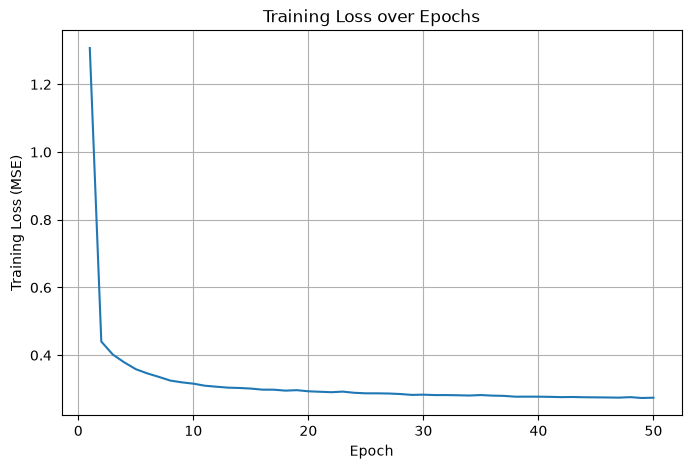

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss (MSE)")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()

## Sample Predictions

We compare a few predictions from the test set against their actual values to get an
intuitive sense of how good (or off) the model's predictions are.

In [14]:
model.eval()
with torch.no_grad():
    sample_X, sample_y = next(iter(test_loader))
    sample_preds = model(sample_X)

comparison = pd.DataFrame({
    "Actual": sample_y.squeeze().numpy()[:10],
    "Predicted": sample_preds.squeeze().numpy()[:10]
})
comparison["Difference"] = comparison["Actual"] - comparison["Predicted"]
comparison

,Actual,Predicted,Difference
0,0.47700,0.613555,-0.136555
1,0.45800,1.001813,-0.543813
2,5.00001,4.517223,0.482787
3,2.18600,2.578319,-0.392319
4,2.78000,3.173686,-0.393686
5,1.58700,1.758744,-0.171744
6,1.98200,2.582282,-0.600282
7,1.57500,1.699680,-0.124680
8,3.40000,2.726171,0.673830
9,4.46600,4.615957,-0.149957


## Conclusion

We built a feed-forward neural network in PyTorch with two hidden layers (32 and 16
units) to predict median house values from the California Housing dataset. The model
was trained for 50 epochs using MSE loss and the Adam optimizer.

- Final training loss: ~0.27
- Test loss: ~0.29 (close to training loss, indicating the model generalizes reasonably
  well and is not overfitting)
- Sample predictions show the model captures the general trend in house values, though
  individual predictions can be off by a noticeable margin.

**What I learned:** how to build a PyTorch Dataset/DataLoader pipeline, define a model
using `nn.Module`, and implement a full training loop (zero_grad → forward → loss →
backward → step).

**Possible improvements:** trying more epochs, a different architecture, or comparing
against a scikit-learn baseline model.